<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Using-the-levers" data-toc-modified-id="Using-the-levers-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Using the levers</a></span></li><li><span><a href="#Taking-a-look-at-Poblats-del-Nord" data-toc-modified-id="Taking-a-look-at-Poblats-del-Nord-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Taking a look at Poblats del Nord</a></span></li><li><span><a href="#Back-to-the-graph" data-toc-modified-id="Back-to-the-graph-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Back to the graph</a></span></li><li><span><a href="#Analyzing-by-neighborhood" data-toc-modified-id="Analyzing-by-neighborhood-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Analyzing by neighborhood</a></span></li><li><span><a href="#Other-factors-affecting-the-price" data-toc-modified-id="Other-factors-affecting-the-price-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Other factors affecting the price</a></span></li><li><span><a href="#Exploiting-the-minicube" data-toc-modified-id="Exploiting-the-minicube-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>Exploiting the minicube</a></span><ul class="toc-item"><li><span><a href="#Number-of-people-you-can-fit" data-toc-modified-id="Number-of-people-you-can-fit-6.1"><span class="toc-item-num">6.1&nbsp;&nbsp;</span>Number of people you can fit</a></span></li></ul></li><li><span><a href="#Impact-of-proximity-to-the-point-of-interest" data-toc-modified-id="Impact-of-proximity-to-the-point-of-interest-7"><span class="toc-item-num">7&nbsp;&nbsp;</span>Impact of proximity to the point of interest</a></span></li></ul></div>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import sqlalchemy as sa

%config IPCompleter.greedy=True

pd.options.display.max_columns = None

In [2]:
con = sa.create_engine('sqlite:///data/airbnbValencia.db')

df = pd.read_sql('df_preparado', con = con)

df.head()

,level_0,index,id,name,host_id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,calculated_host_listings_count,availability_365,description,host_is_superhost,accommodates,bathrooms,bedrooms,beds,number_of_reviews,review_scores_rating,review_scores_communication,review_scores_location,precio_m2,distrito,precio_total,ocupacion,bedrooms_disc,accommodates_disc,beds_disc,number_of_reviews_disc,m2,precio_compra,pdi_arts
0,0,0,48154,Precioso apartamento con wifi,219476,LA SAIDIA,MORVEDRE,39.48375,-0.37502,Entire home/apt,92.0,3,4,81,Second floor on a farm from the late 19th cent...,f,4,1.0,2.0,2.0,161,4.60,4.78,4.49,2479,LA SAIDIA,92.0,77,02_Dos,3-4,2-3,2-37,70,121471.0,3.890754
1,1,1,136378,Old City Charm with Modern Comfort,591197,CIUTAT VELLA,EL MERCAT,39.47358,-0.37815,Entire home/apt,75.0,28,2,0,None,f,3,1.0,1.0,2.0,25,4.46,4.80,4.84,3832,CIUTAT VELLA,75.0,100,01_Uno,3-4,2-3,2-37,50,134120.0,3.202849
2,2,2,149715,1900 Style Valencian Beach Home for 10px,5947,POBLATS MARITIMS,CABANYAL-CANYAMELAR,39.46746,-0.32813,Entire home/apt,269.0,2,1,260,Typical town house with 5 bedrooms and 3 and a...,f,10,4.0,5.0,7.0,259,4.66,4.89,4.59,2662,POBLATS MARITIMS,269.0,28,04_Cuatro_o_mas,5-16,4-31,38-860,160,298144.0,2.390186
3,3,3,165971,★ Architectural touch! ★,791187,EXTRAMURS,LA ROQUETA,39.46790,-0.38206,Entire home/apt,132.0,5,7,16,"Hola! I am ready to welcome you in my apt., wh...",None,5,1.0,1.0,1.0,517,4.87,4.87,4.83,3125,EXTRAMURS,132.0,95,01_Uno,5-16,0-1,0-1,50,109375.0,3.112647
4,4,4,182221,Apartments Calatrava City Valencia,1315567,CAMINS AL GRAU,AIORA,39.46343,-0.34325,Entire home/apt,180.0,3,2,336,None,f,5,1.0,2.0,5.0,8,4.50,4.63,4.25,2896,CAMINS AL GRAU,180.0,7,02_Dos,5-16,4-31,38-860,70,141904.0,1.167519


In [3]:
from sqlalchemy import inspect
insp = inspect(con)
tablas = insp.get_table_names()
tablas

['df', 'df_mergeado', 'df_preparado', 'listings', 'listings_det']

### Using the levers

Cosa de precio, como cambia todo según precio y tal. Vamos a intentar encontrar oportunidades en plan precios bajos con posibilidades de poner el alquiler alto

In [4]:
df.precio_total.describe()

count    9002.000000
mean      125.028072
std       136.221188
min        20.000000
25%        65.000000
50%       106.000000
75%       150.000000
max      6286.000000
Name: precio_total, dtype: float64

In [5]:
# the mean is odd, because the std is very high
# this indicates that there must be outliers

In [6]:
df.precio_total.median()


106.0

In [7]:
# 106 rent per night

# either we start working with outliers or we stick with the median
# in this case we are going to do it, given what we know

In [8]:

df.groupby('distrito').precio_total.median().sort_values(ascending = False)




distrito
POBLATS DEL NORD     130.0
LA SAIDIA            123.0
CIUTAT VELLA         120.0
POBLATS MARITIMS     120.0
L'EIXAMPLE           118.5
EXTRAMURS            106.5
CAMINS AL GRAU       104.0
BENIMACLET           101.5
POBLATS DEL SUD      101.0
QUATRE CARRERES       96.0
CAMPANAR              92.0
POBLATS DE L'OEST     91.0
ALGIROS               85.5
EL PLA DEL REAL       85.5
BENICALAP             85.0
PATRAIX               76.5
JESUS                 74.0
RASCANYA              70.0
L'OLIVERETA           54.0
Name: precio_total, dtype: float64

I don't know much about Valencia, so I don't see anything unusual here. I would perhaps have to do some research.

In any case, one can always compare with the average property price or proximity to points of interest.

In [9]:
# let's see prices

temp = df.groupby('distrito')[['precio_total','precio_compra']].median()
temp

,precio_total,precio_compra
distrito,,
ALGIROS,85.5,97720.0
BENICALAP,85.0,73920.0
BENIMACLET,101.5,129507.0
CAMINS AL GRAU,104.0,101360.0
CAMPANAR,92.0,100450.0
CIUTAT VELLA,120.0,134120.0
EL PLA DEL REAL,85.5,123690.0
EXTRAMURS,106.5,109375.0
JESUS,74.0,72730.0


''

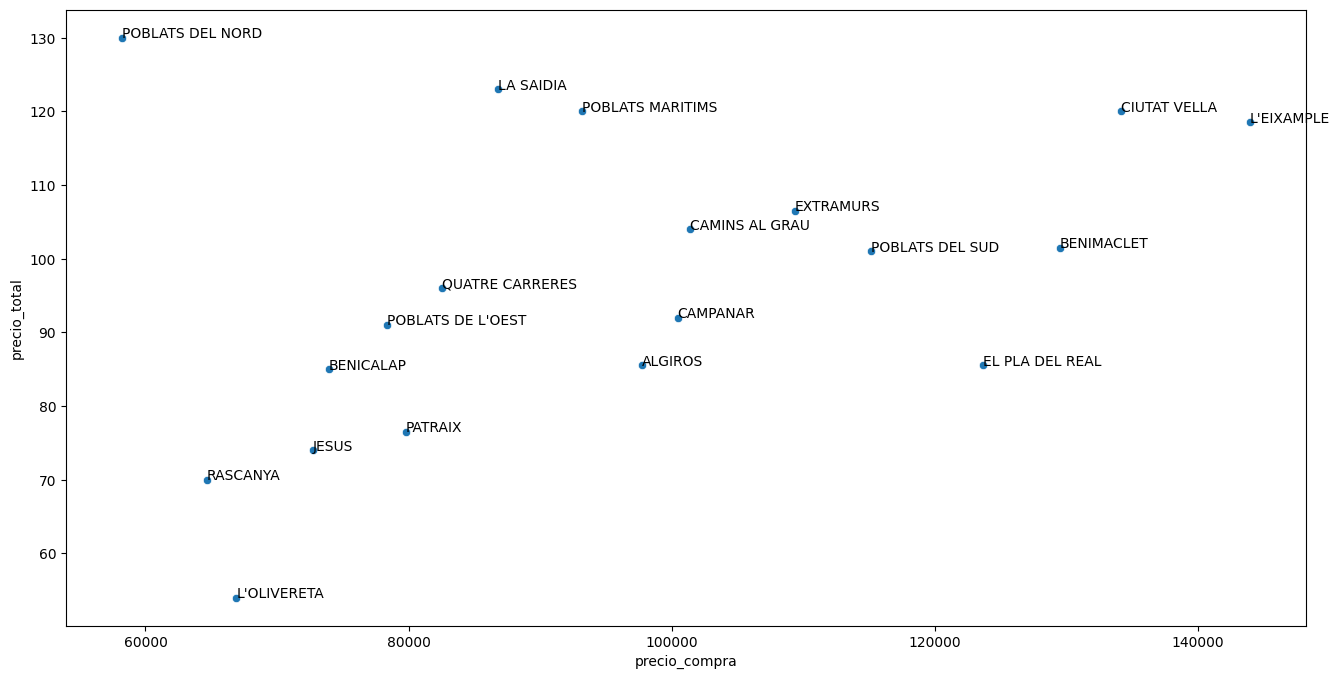

In [10]:
# ok here it is interesting to find places where
# the rental price does not change much but is cheaper

plt.figure(figsize = (16,8))
sns.scatterplot(data = temp, x='precio_compra', y = 'precio_total')

# let's put labels on the points to see which is which
# there is some crazy point, the low price buy high price rent is interesting

for cada in range(0,temp.shape[0]):
    plt.text(temp.precio_compra.iloc[cada], temp.precio_total.iloc[cada], temp.index[cada])

;



### Taking a look at Poblats del Nord

In [11]:
# What is going on with Poblats del Nord?
# Its purchase price is low but its rent is very high

In [12]:


df.loc[df.distrito == 'POBLATS DEL NORD'].sort_values('precio_total',ascending = False).head(10)



,level_0,index,id,name,host_id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,calculated_host_listings_count,availability_365,description,host_is_superhost,accommodates,bathrooms,bedrooms,beds,number_of_reviews,review_scores_rating,review_scores_communication,review_scores_location,precio_m2,distrito,precio_total,ocupacion,bedrooms_disc,accommodates_disc,beds_disc,number_of_reviews_disc,m2,precio_compra,pdi_arts
7447,7447,7447,1105228691252179974,"NEW VLC Apart - Cervero 24A, Apart 104",542811646,POBLATS DEL NORD,POBLE NOU,39.500483,-0.388734,Entire home/apt,583.0,1,7,315,This stylish place is perfect for groups.,f,10,1.0,1.0,5.0,1,4.00,5.00,4.00,1664,POBLATS DEL NORD,583.0,13,01_Uno,5-16,4-31,38-860,50,58240.0,6.092770
1101,1101,1101,22409066,CASUAL HOUSE,164034271,POBLATS DEL NORD,CARPESA,39.515850,-0.377860,Entire home/apt,400.0,2,1,131,Casual House is located in l 'horta de Valenci...,f,9,2.0,3.0,5.0,23,4.74,4.96,4.43,1664,POBLATS DEL NORD,400.0,64,03_Tres,5-16,4-31,38-860,90,104832.0,7.228696
4915,4915,4915,891348469795051729,Casa Mediterranea en Valencia,7617037,POBLATS DEL NORD,CARPESA,39.505024,-0.376241,Entire home/apt,320.0,2,1,172,Renovated grocery store in the middle of Valen...,f,8,3.0,3.0,4.0,1,3.00,4.00,4.00,1664,POBLATS DEL NORD,320.0,52,03_Tres,5-16,4-31,38-860,90,104832.0,6.051233
3469,3469,3469,641344261538300181,Autocaravana Rustic Escapes,462421478,POBLATS DEL NORD,MASSARROJOS,39.547770,-0.417710,Entire home/apt,160.0,2,1,90,Reconnect with nature with this unforgettable ...,f,4,1.0,1.0,2.0,0,NaN,NaN,NaN,1664,POBLATS DEL NORD,160.0,75,01_Uno,3-4,2-3,2-37,50,58240.0,11.884547
6023,6023,6023,996900137094384814,El Campet,21533558,POBLATS DEL NORD,MASSARROJOS,39.538846,-0.407293,Entire home/apt,131.0,3,1,89,"Mediterranean-style wooden house, located a 5-...",f,4,1.0,2.0,2.0,0,NaN,NaN,NaN,1664,POBLATS DEL NORD,131.0,75,02_Dos,3-4,2-3,2-37,70,81536.0,10.586621
912,912,912,19223606,Charming country house 15 minutes from Valencia,1383826,POBLATS DEL NORD,MAHUELLA-TAULADELLA,39.542854,-0.334211,Entire home/apt,130.0,7,1,232,Recently refurbished home in country location ...,f,7,3.5,3.0,5.0,24,4.88,4.92,4.88,1664,POBLATS DEL NORD,130.0,36,03_Tres,5-16,4-31,38-860,90,104832.0,9.929726
459,459,459,12259478,Buhardilla Silenciosa y luminosa.,66014145,POBLATS DEL NORD,MASSARROJOS,39.545790,-0.414450,Private room,49.0,1,1,327,If you want to enjoy Tranquility and silence h...,t,3,1.0,1.0,2.0,76,4.99,4.99,4.75,1664,POBLATS DEL NORD,49.0,10,01_Uno,3-4,2-3,2-37,50,58240.0,11.556802
7394,7394,7394,1102218537926371946,Habitación para una sola persona (chica),351167597,POBLATS DEL NORD,POBLE NOU,39.499918,-0.371473,Private room,40.0,1,1,270,"Outdoor, quiet, comfortable and single room is...",f,1,1.0,1.0,1.0,0,NaN,NaN,NaN,1664,POBLATS DEL NORD,40.0,26,01_Uno,1-2,0-1,0-1,50,58240.0,5.375268
2609,2609,2609,50145916,Alquilo Hab. pequeñ 30e cerca c.c Arena 5km d ...,404667487,POBLATS DEL NORD,POBLE NOU,39.502070,-0.371350,Private room,30.0,1,1,365,small room (30 PER PERSON) has a sofa bed and...,f,2,1.0,1.0,2.0,26,4.50,4.58,4.04,1664,POBLATS DEL NORD,30.0,0,01_Uno,1-2,2-3,2-37,50,58240.0,5.597621
4638,4638,4638,858709513078888726,Habitación para chicas,507805547,POBLATS DEL NORD,POBLE NOU,39.500380,-0.371180,Private room,30.0,1,1,365,"Room only for girls, bright and quiet and with...",f,1,1.5,1.0,0.0,0,NaN,NaN,NaN,1664,POBLATS DEL NORD,30.0,0,01_Uno,1-2,0-1,0-1,50,58240.0,5.415228


In [13]:
# it seems that there are enough apartments here for many people
# it is possible that this is skewing the result of the purchase price
# it would be necessary to investigate with external data a little

# I want a graph that shows the number of accommodates in these


df.loc[df.distrito == 'POBLATS DEL NORD'].accommodates.describe()



count    11.000000
mean      4.636364
std       3.294624
min       1.000000
25%       2.000000
50%       4.000000
75%       7.500000
max      10.000000
Name: accommodates, dtype: float64

In [14]:
# ok, an average of 5 tenants (the median matches)

print('cantidad de pisos aquí: ',
      len(df.loc[df.distrito == 'POBLATS DEL NORD']))

cantidad de pisos aquí:  11


In [15]:
df.loc[df.distrito == 'POBLATS DEL NORD'].accommodates.value_counts()


accommodates
2     2
4     2
1     2
3     1
7     1
9     1
8     1
10    1
Name: count, dtype: int64

In [16]:
# there are very few apartments, too,
# I don't think you can get much from here

### Back to the graph


''

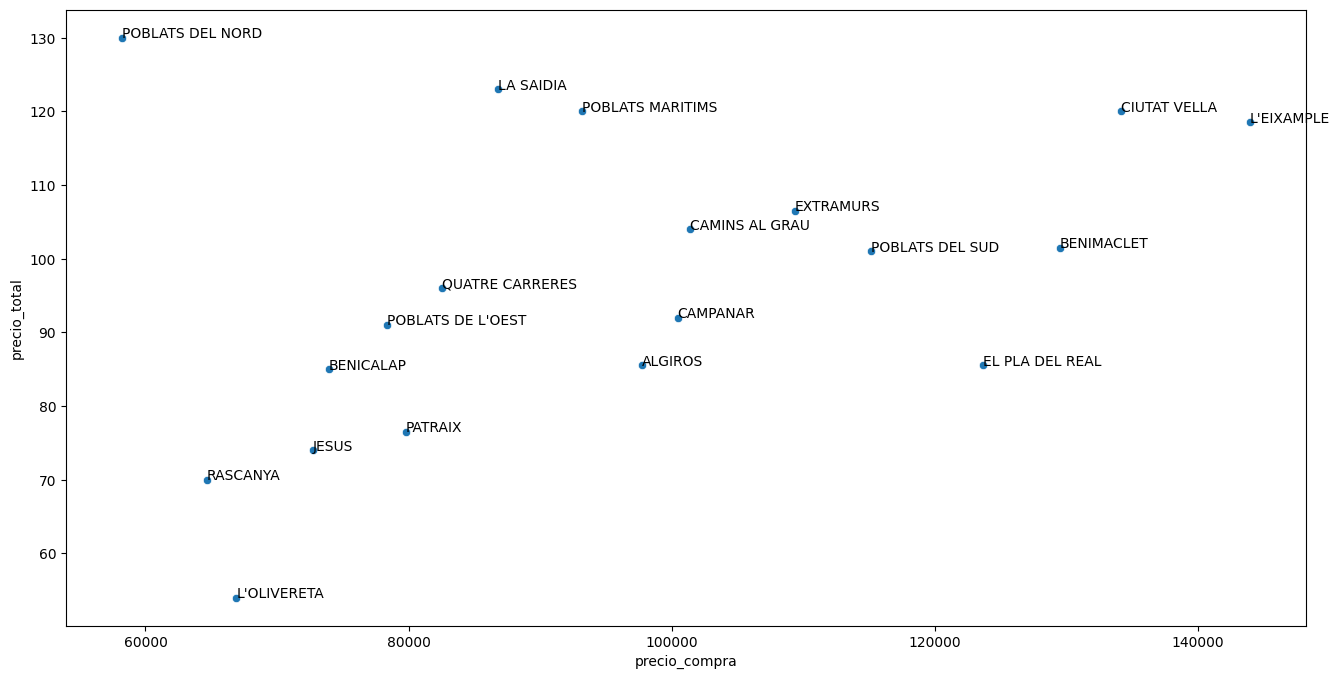

In [17]:
plt.figure(figsize = (16,8))
sns.scatterplot(data = temp, x='precio_compra', y = 'precio_total')

# let's put labels on the points to see which is which
# there is some crazy point, the low price buy high price rent is interesting

for cada in range(0,temp.shape[0]):
    plt.text(temp.precio_compra.iloc[cada], temp.precio_total.iloc[cada], temp.index[cada])

;



We see that we could identify three blocks: a part on the left where prices and costs are low and are rising; a flatter part (surprisingly, in Madrid it is steeper) that corresponds to a midpoint (and here we would be interested in seeing what happens with La Saidia and Poblats Marítims, which are supposedly not so expensive to buy and have sky-high prices); and a third, already super-high fragment of Ciutat Vella and L'Eixamlpe, which are already urban areas.

### Analyzing by neighborhood

In [18]:
tempBarrio = df.groupby('neighbourhood')[['precio_total','precio_compra']].median()
tempBarrio.head(20)


,precio_total,precio_compra
neighbourhood,,
AIORA,102.0,101360.0
ALBORS,89.5,101360.0
ARRANCAPINS,95.2,109375.0
BENICALAP,85.5,73920.0
BENIFERRI,123.0,78351.0
BENIMACLET,103.0,129507.0
BENIMAMET,79.5,67158.0
BETERO,112.5,130438.0
CABANYAL-CANYAMELAR,122.0,93170.0


''

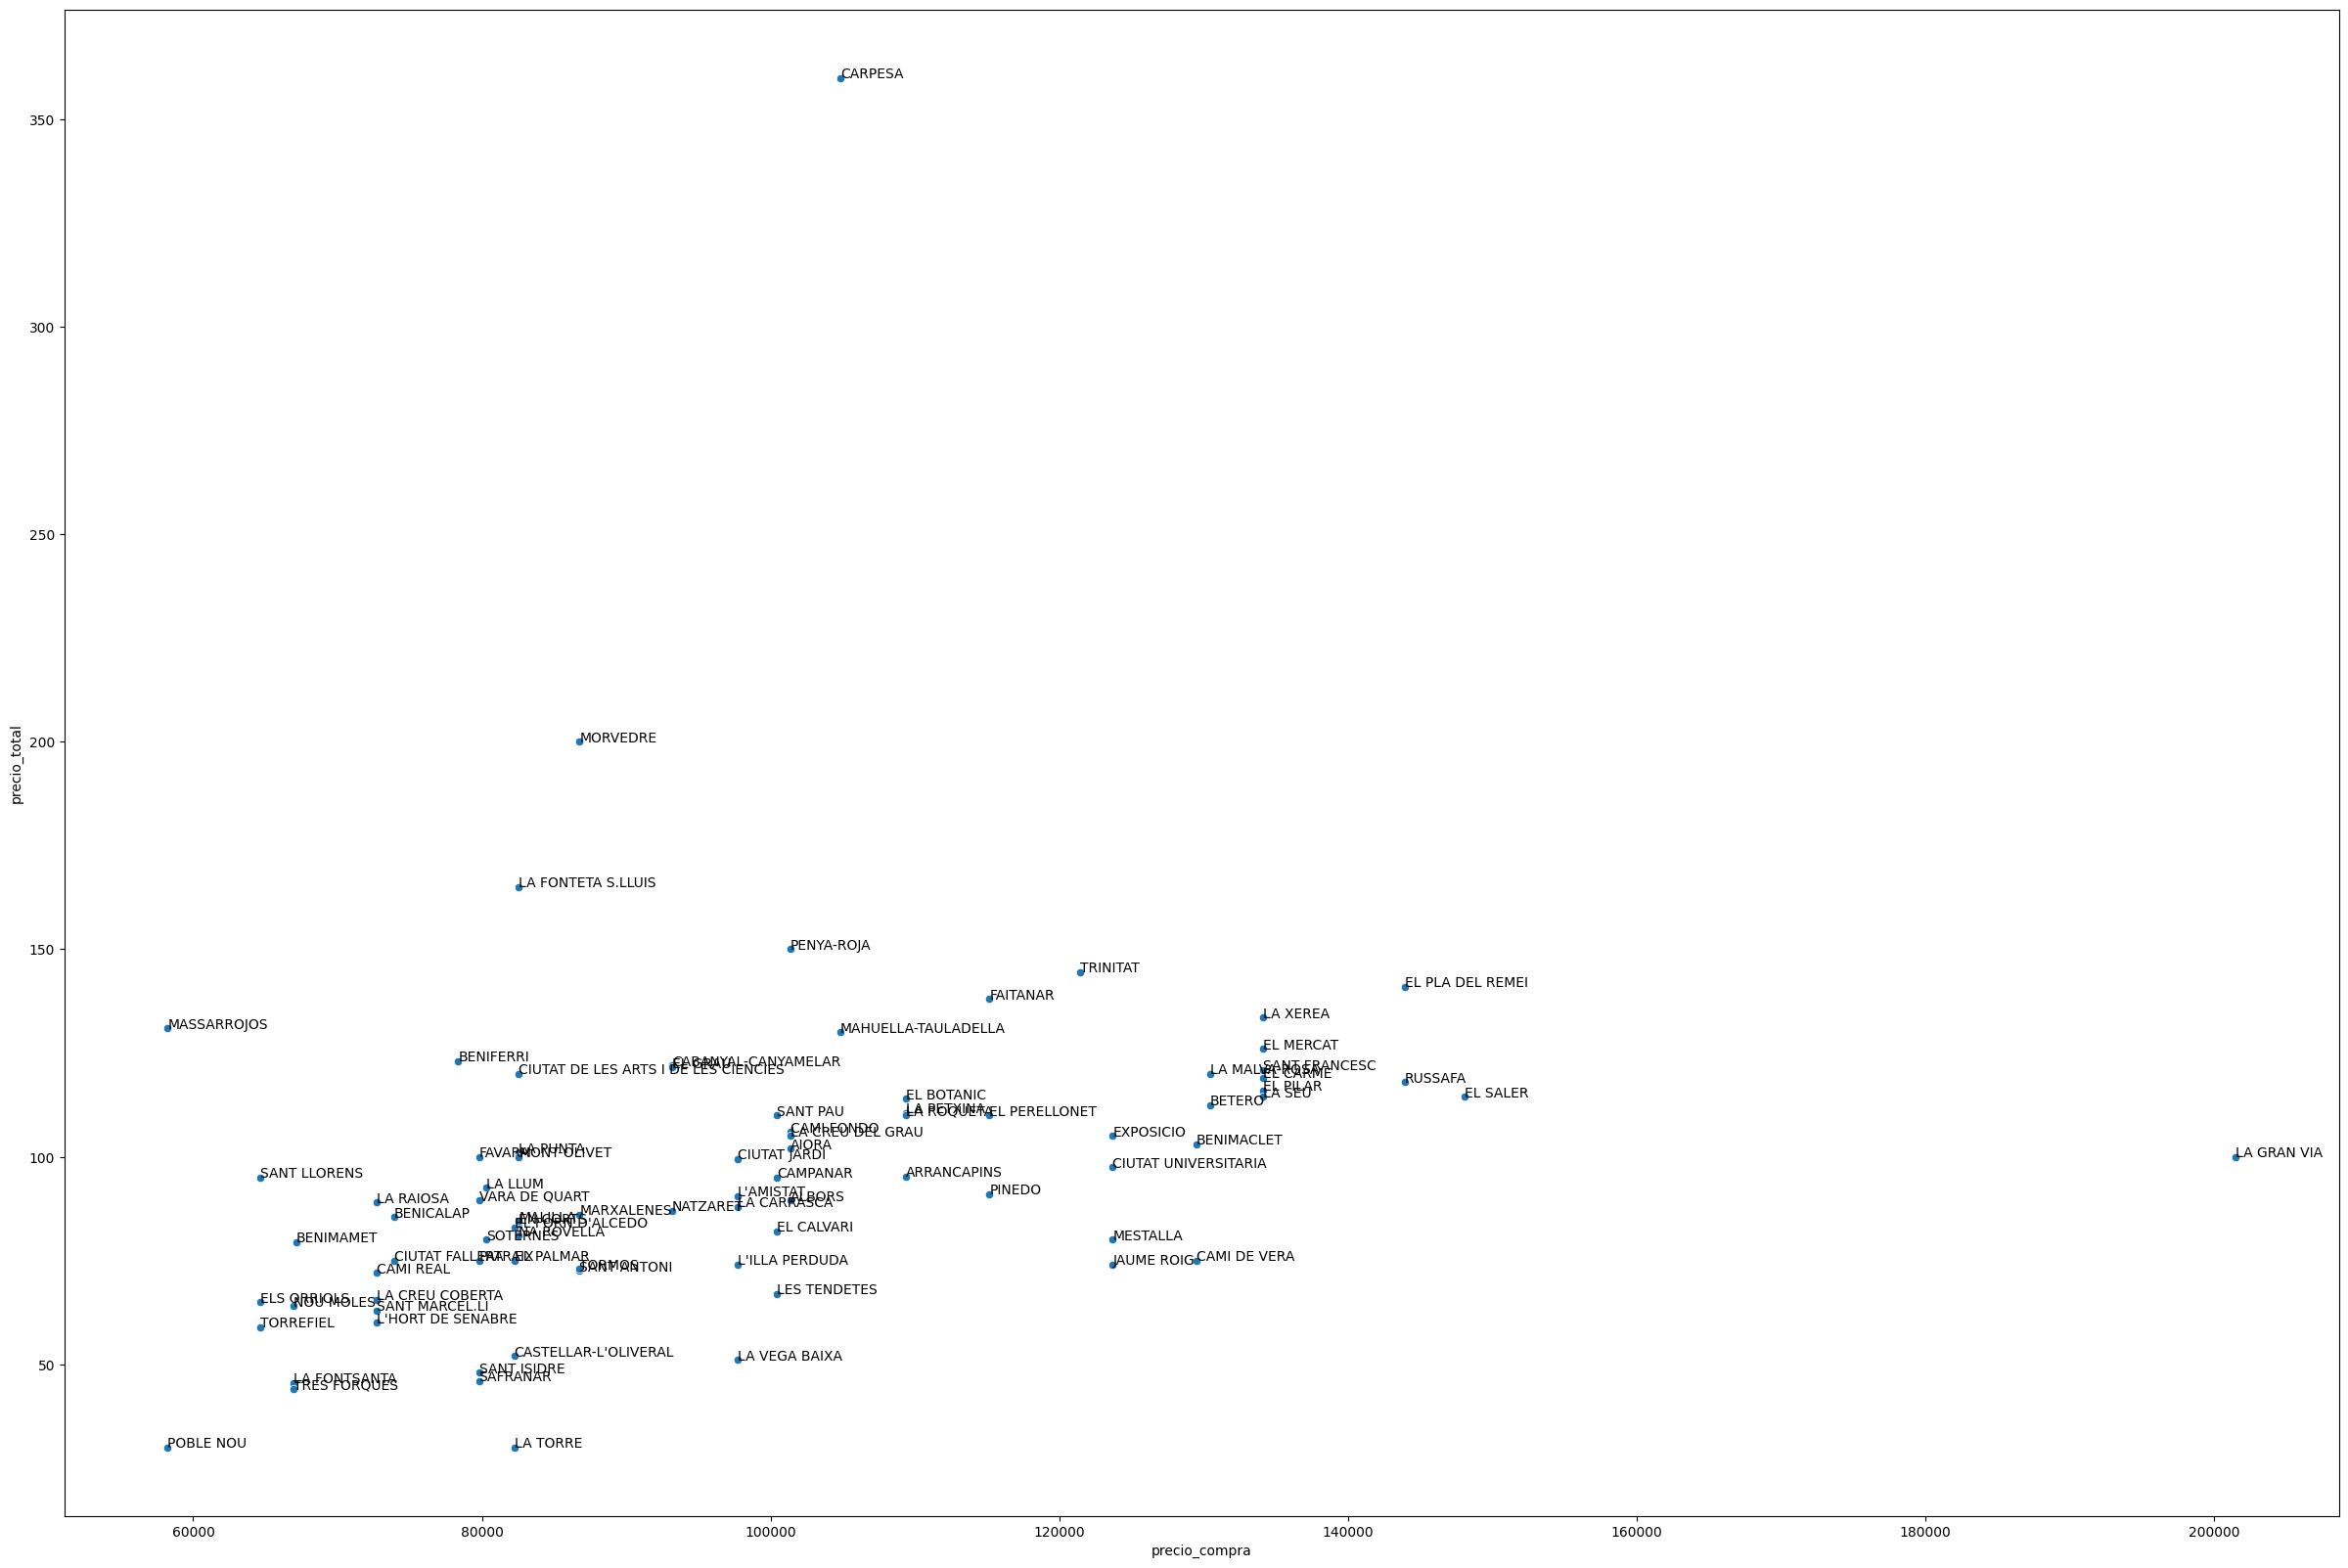

In [19]:
plt.figure(figsize = (30,20))
sns.scatterplot(data = tempBarrio, x='precio_compra', y = 'precio_total')

for cada in range(0,tempBarrio.shape[0]):
    plt.text(tempBarrio.precio_compra.iloc[cada], tempBarrio.precio_total.iloc[cada], tempBarrio.index[cada])

;


From here we can get insights, we can identify (excluding the atypical ones from the periphery that many people see, which is also an option) for each category (low-medium-high) some neighborhoods that offer better profitability. This is insight because it is what they asked us when they asked us to do this analysis.

### Other factors affecting the price

In [20]:
df.filter(like = "disc")

,bedrooms_disc,accommodates_disc,beds_disc,number_of_reviews_disc
0,02_Dos,3-4,2-3,2-37
1,01_Uno,3-4,2-3,2-37
2,04_Cuatro_o_mas,5-16,4-31,38-860
3,01_Uno,5-16,0-1,0-1
4,02_Dos,5-16,4-31,38-860
...,...,...,...,...
8997,01_Uno,1-2,0-1,0-1
8998,01_Uno,1-2,0-1,0-1
8999,01_Uno,1-2,0-1,0-1
9000,04_Cuatro_o_mas,5-16,4-31,38-860


In [21]:
# let's use this as an excuse to practice making a minicube.
# the minicube is more useful when instead of 3 we have 30 variables

In [22]:

metricas = ['precio_total', 'precio_compra']

dimensiones = ['bedrooms_disc','accommodates_disc','beds_disc']

minicubo_precio = df[dimensiones + metricas]

minicubo_precio



,bedrooms_disc,accommodates_disc,beds_disc,precio_total,precio_compra
0,02_Dos,3-4,2-3,92.0,121471.0
1,01_Uno,3-4,2-3,75.0,134120.0
2,04_Cuatro_o_mas,5-16,4-31,269.0,298144.0
3,01_Uno,5-16,0-1,132.0,109375.0
4,02_Dos,5-16,4-31,180.0,141904.0
...,...,...,...,...,...
8997,01_Uno,1-2,0-1,90.0,64680.0
8998,01_Uno,1-2,0-1,39.0,101360.0
8999,01_Uno,1-2,0-1,57.0,64680.0
9000,04_Cuatro_o_mas,5-16,4-31,400.0,321888.0


In [23]:

minicubo_precio_transaccional = minicubo_precio.melt(id_vars = metricas)
minicubo_precio_transaccional


,precio_total,precio_compra,variable,value
0,92.0,121471.0,bedrooms_disc,02_Dos
1,75.0,134120.0,bedrooms_disc,01_Uno
2,269.0,298144.0,bedrooms_disc,04_Cuatro_o_mas
3,132.0,109375.0,bedrooms_disc,01_Uno
4,180.0,141904.0,bedrooms_disc,02_Dos
...,...,...,...,...
27001,90.0,64680.0,beds_disc,0-1
27002,39.0,101360.0,beds_disc,0-1
27003,57.0,64680.0,beds_disc,0-1
27004,400.0,321888.0,beds_disc,4-31


In [24]:

minicubo = minicubo_precio_transaccional.groupby(['variable', 'value'])\
            [metricas].agg('median')

minicubo



precio_total  precio_compra
variable          value                                       
accommodates_disc 1-2                      59.0        97720.0
                  3-4                     116.0       130438.0
                  5-16                    150.0       167706.0
bedrooms_disc     01_Uno                   83.0        93170.0
                  02_Dos                  127.0       140630.0
                  03_Tres                 141.0       167706.0
                  04_Cuatro_o_mas         170.0       243264.0
beds_disc         0-1                      69.0       101360.0
                  2-3                     121.0       130438.0
                  4-31                    151.5       180810.0

### Exploiting the minicube


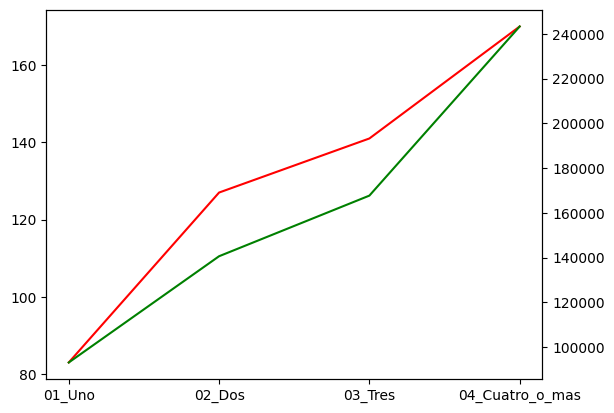

In [25]:


f, ax = plt.subplots()

ax.plot(minicubo.loc['bedrooms_disc'].precio_total, color = 'red')

ax2 = ax.twinx()
ax2.plot(minicubo.loc['bedrooms_disc'].precio_compra, color = 'green')

# they are related, in fact we use it as a proxy
# the fact that this relationship appears confirms that they were related
# (num rooms with price and such)

# they overlap for him, but not for me, it would be necessary to think about this a bit
# or well, what does it matter

# of course, something is going on here.
# I'll leave thinking about it for another day


In [26]:
minicubo.loc['beds_disc']

,precio_total,precio_compra
value,,
0-1,69.0,101360.0
2-3,121.0,130438.0
4-31,151.5,180810.0


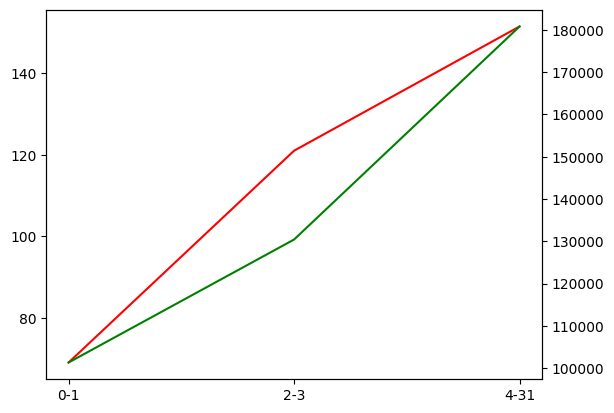

In [27]:
f, ax = plt.subplots()

ax.plot(minicubo.loc['beds_disc'].precio_total, color = 'red')

ax2 = ax.twinx()
ax2.plot(minicubo.loc['beds_disc'].precio_compra, color = 'green')


The rental price peaks at 2-3, while the price drops at 2-3.
In Madrid, this is the other way around.

It also happens that I have not distinguished between 2 or 3


<Axes: xlabel='beds'>

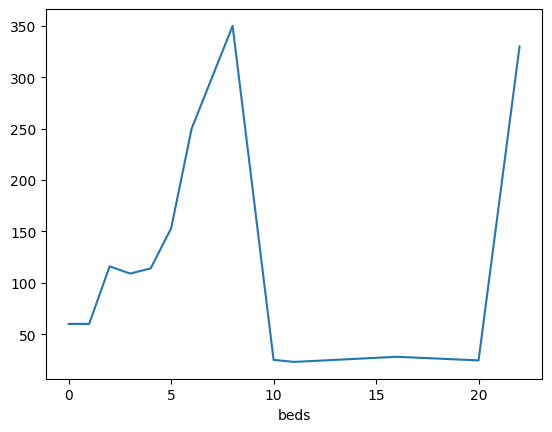

In [28]:
df[df.bedrooms == 1].groupby('beds').precio_total.median().plot()

Well, we can ignore the weird thing starting at 9-10.
Before that it increases linearly, which makes sense.

There's some thread to pull on here, **it seems people are putting in a lot of beds**

#### Number of people you can fit

In [29]:
minicubo.loc['accommodates_disc']

,precio_total,precio_compra
value,,
1-2,59.0,97720.0
3-4,116.0,130438.0
5-16,150.0,167706.0


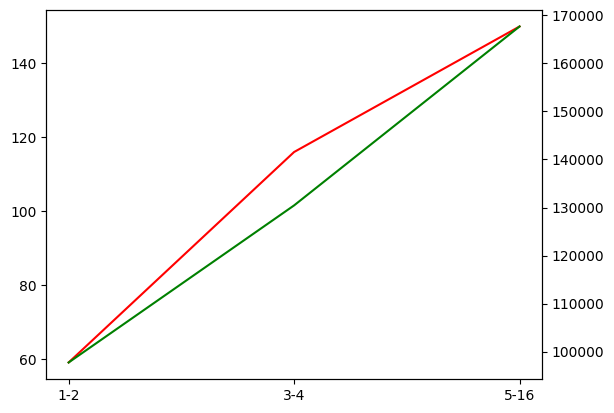

In [30]:
f, ax = plt.subplots()

ax.plot(minicubo.loc['accommodates_disc'].precio_total, color = 'red')

ax2 = ax.twinx()
ax2.plot(minicubo.loc['accommodates_disc'].precio_compra, color = 'green')


It seems that 3-4 is where there is the best profitability. Perhaps it would be useful and not take much time to not discretize directly, and see if the pattern continues to be fulfilled.

It is not even that there is an advantage, I think that from here we can only extract that clearly the benefit of going from 1-2 to 3-4 is greater than that of going from 3-4 to the next

### Impact of proximity to the point of interest



The best thing would have been to build more of these, in a real case. Here, the truth is that I don't think that the proximity to arts i ciencies will have much of an effect.

In [31]:
df.groupby('distrito').pdi_arts.median().sort_values()

distrito
CAMINS AL GRAU        1.315031
QUATRE CARRERES       1.499591
ALGIROS               2.065601
L'EIXAMPLE            2.175139
EL PLA DEL REAL       2.218498
POBLATS MARITIMS      2.325160
JESUS                 3.263910
CIUTAT VELLA          3.270603
EXTRAMURS             3.431971
BENIMACLET            3.567955
PATRAIX               3.729017
LA SAIDIA             4.001610
L'OLIVERETA           4.566739
CAMPANAR              4.791867
RASCANYA              4.793056
BENICALAP             5.619823
POBLATS DEL NORD      6.777909
POBLATS DE L'OEST     7.852815
POBLATS DEL SUD      14.906613
Name: pdi_arts, dtype: float64

In [32]:
# we're going to catch up to El pla del real

seleccion = df.groupby('distrito').pdi_arts.median().sort_values()[0:7].index.to_list()
seleccion



['CAMINS AL GRAU',
 'QUATRE CARRERES',
 'ALGIROS',
 "L'EIXAMPLE",
 'EL PLA DEL REAL',
 'POBLATS MARITIMS',
 'JESUS']

<Axes: xlabel='pdi_arts', ylabel='precio_total'>

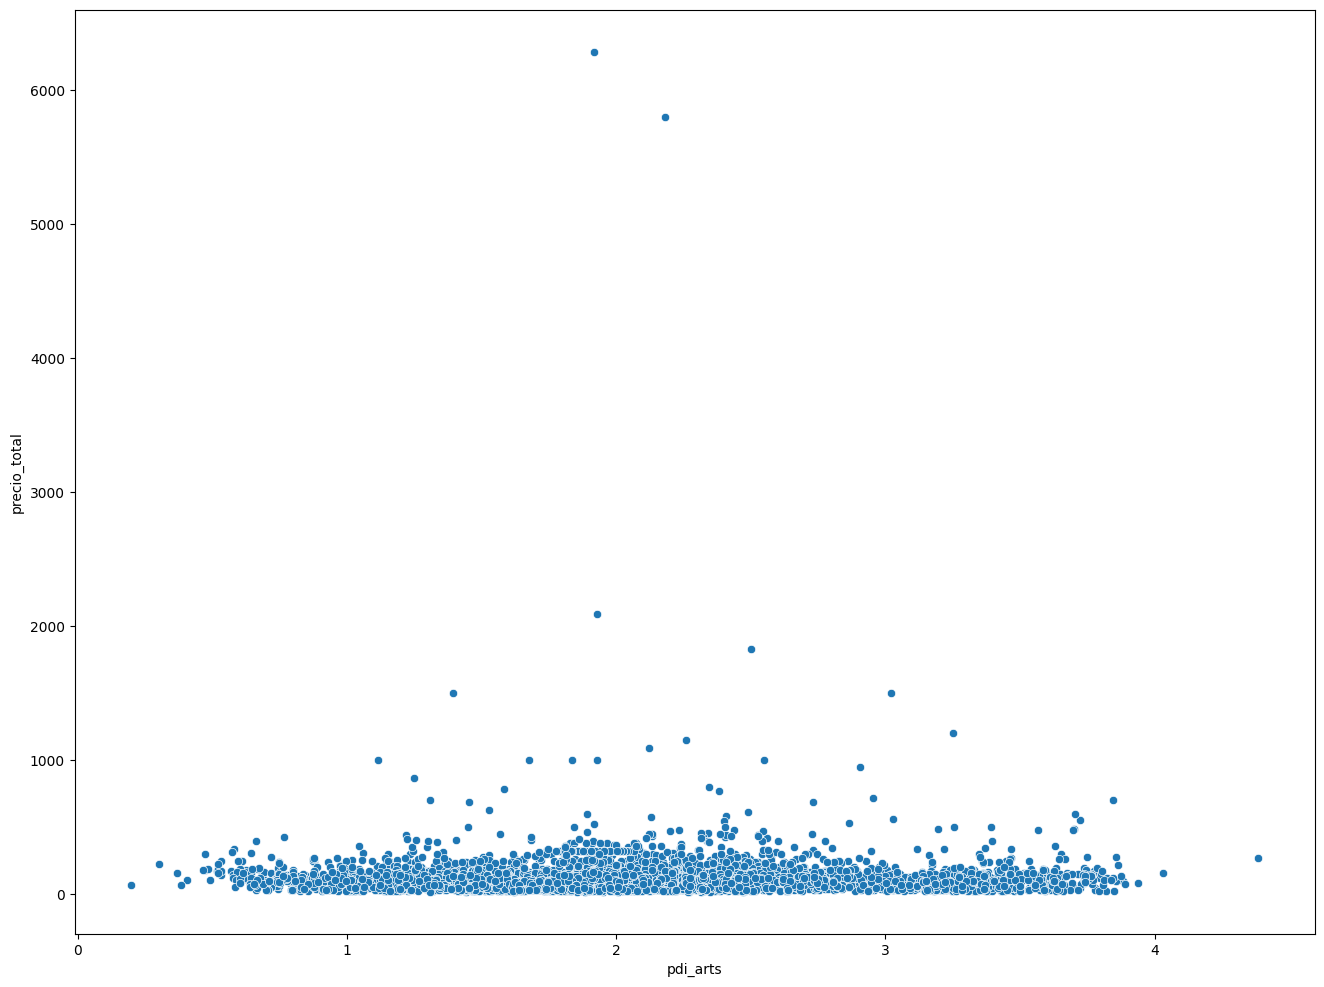

In [33]:

plt.figure(figsize = (16,12))
sns.scatterplot(
    data = df.loc[df.distrito.isin(seleccion)], 
    x = "pdi_arts", 
    y = "precio_total")



It seems that there is not much of a relationship between distance and price. At most, you can see that there is a higher price at 2km, which must coincide with the city centre or something like that.

Again, this is an example, there are probably more factors that should be analysed and other points of interest.

In [34]:
# we are going to do a map thing, for this we install folium

# conda install -c conda-forge folium

In [35]:
import folium

In [36]:
folium.Map(location=[39.483750, -0.375020], zoom_start=12)

In [37]:
datos = df[df.distrito == 'POBLATS MARITIMS'].copy()

In [38]:
mapa = folium.Map(location=[39.483750, -0.375020],zoom_start=12)

for piso in range(0,len(datos)):
   folium.Marker(
      location = [datos.iloc[piso]['latitude'], datos.iloc[piso]['longitude']],
      popup = datos.iloc[piso]['precio_total'],
   ).add_to(mapa)

mapa

In [39]:

datos['precio_total_disc'] = pd.qcut(datos['precio_total'], q = [0, .25, .5, .75, 1.], 
                              labels=['lime', 'yellow', 'orange', 'red'])


In [40]:

mapa = folium.Map(location=[39.483750, -0.375020],zoom_start=12)

for piso in range(0,len(datos)):
   folium.CircleMarker(
      location = [datos.iloc[piso]['latitude'], datos.iloc[piso]['longitude']],
      popup = datos.iloc[piso]['precio_total'],
      fill=True,
      color = datos.iloc[piso]['precio_total_disc'],
      fill_opacity=1,
      radius = 5
   ).add_to(mapa)

mapa
